In [1]:
import numpy as np
import scipy
import pandas 
import moments
import dpluspy

In [2]:
import matplotlib, matplotlib.pylab as plt

plt.rcParams["legend.title_fontsize"] = "small"
matplotlib.rc("xtick", labelsize=9)
matplotlib.rc("ytick", labelsize=9)
matplotlib.rc("axes", labelsize=9)
matplotlib.rc("axes", titlesize=9)
matplotlib.rc("legend", fontsize=7)
plt.rcParams['legend.title_fontsize'] = 'small'

In [125]:
# Concatenate LRT adjustment summaries together
models = [
    "pulse",
    "asymmetric_migration",
    "migration",
    "contraction",
    "asymmetric_sizes",
]
for model in models:
    for submodel in [0, 1]:
        tbls = []
        for ii in range(100):
            fname = f"{model}/trials/model{submodel}_{ii}_LRT.csv"
            try:
                tbl = pandas.read_csv(fname)
                tbls.append(tbl)
            except:
                print(f"Missing file {fname}")
        concat_tbl = pandas.concat(tbls)
        concat_tbl.to_csv(f"{model}_model{submodel}_LRT.csv", index=False)

Missing file pulse/trials/model0_6_LRT.csv
Missing file pulse/trials/model0_21_LRT.csv
Missing file pulse/trials/model0_23_LRT.csv
Missing file pulse/trials/model0_30_LRT.csv
Missing file pulse/trials/model0_47_LRT.csv
Missing file pulse/trials/model0_49_LRT.csv
Missing file pulse/trials/model0_50_LRT.csv
Missing file pulse/trials/model0_55_LRT.csv
Missing file pulse/trials/model0_56_LRT.csv
Missing file pulse/trials/model0_66_LRT.csv
Missing file pulse/trials/model0_71_LRT.csv
Missing file pulse/trials/model0_73_LRT.csv
Missing file pulse/trials/model0_75_LRT.csv
Missing file pulse/trials/model0_80_LRT.csv
Missing file pulse/trials/model0_91_LRT.csv
Missing file pulse/trials/model0_92_LRT.csv
Missing file pulse/trials/model0_93_LRT.csv
Missing file pulse/trials/model0_96_LRT.csv
Missing file pulse/trials/model0_99_LRT.csv
Missing file asymmetric_migration/trials/model0_11_LRT.csv
Missing file asymmetric_migration/trials/model0_18_LRT.csv
Missing file asymmetric_migration/trials/model0

In [151]:
# Summarize bootstrap LRT and concatenate together
for model in models:
    for submodel in [0, 1]:
        reps = []
        for ii in range(100):
            fname = f"{model}/trials/model{submodel}_{ii}_bootstrapLRT.csv"
            try:
                tbl = pandas.read_csv(fname)
                Dstats = 2 * (np.array(tbl["ll1"]) - np.array(tbl["ll0"]))
                reps.append(Dstats)
            except:
                print(f"Missing file {fname}")
        summary_tbl = pandas.DataFrame(
            {f"rep{i}": reps[i] for i in range(len(reps))})
        summary_tbl.to_csv(
            f"{model}_model{submodel}_bootstrapLRT.csv", index=False)

Missing file pulse/trials/model0_6_bootstrapLRT.csv
Missing file pulse/trials/model0_21_bootstrapLRT.csv
Missing file pulse/trials/model0_23_bootstrapLRT.csv
Missing file pulse/trials/model0_30_bootstrapLRT.csv
Missing file pulse/trials/model0_47_bootstrapLRT.csv
Missing file pulse/trials/model0_49_bootstrapLRT.csv
Missing file pulse/trials/model0_50_bootstrapLRT.csv
Missing file pulse/trials/model0_55_bootstrapLRT.csv
Missing file pulse/trials/model0_56_bootstrapLRT.csv
Missing file pulse/trials/model0_66_bootstrapLRT.csv
Missing file pulse/trials/model0_71_bootstrapLRT.csv
Missing file pulse/trials/model0_73_bootstrapLRT.csv
Missing file pulse/trials/model0_75_bootstrapLRT.csv
Missing file pulse/trials/model0_80_bootstrapLRT.csv
Missing file pulse/trials/model0_91_bootstrapLRT.csv
Missing file pulse/trials/model0_92_bootstrapLRT.csv
Missing file pulse/trials/model0_93_bootstrapLRT.csv
Missing file pulse/trials/model0_96_bootstrapLRT.csv
Missing file pulse/trials/model0_99_bootstrapLR

In [3]:
# Reload data
asymmetric_size_0_df = pandas.read_csv("asymmetric_sizes_model0_LRT.csv")
asymmetric_size_1_df = pandas.read_csv("asymmetric_sizes_model1_LRT.csv")
asymmetric_size_0_boot_df = pandas.read_csv("asymmetric_sizes_model0_bootstrapLRT.csv")
asymmetric_size_1_boot_df = pandas.read_csv("asymmetric_sizes_model1_bootstrapLRT.csv")

migration_0_df = pandas.read_csv("migration_model0_LRT.csv")
migration_1_df = pandas.read_csv("migration_model1_LRT.csv")
migration_0_boot_df = pandas.read_csv("migration_model0_bootstrapLRT.csv")
migration_1_boot_df = pandas.read_csv("migration_model1_bootstrapLRT.csv")

contraction_0_df = pandas.read_csv("contraction_model0_LRT.csv")
contraction_1_df = pandas.read_csv("contraction_model1_LRT.csv")
contraction_0_boot_df = pandas.read_csv("contraction_model0_bootstrapLRT.csv")
contraction_1_boot_df = pandas.read_csv("contraction_model1_bootstrapLRT.csv")

pulse_0_df = pandas.read_csv("pulse_model0_LRT.csv")
pulse_1_df = pandas.read_csv("pulse_model1_LRT.csv")
pulse_0_boot_df = pandas.read_csv("pulse_model0_bootstrapLRT.csv")
pulse_1_boot_df = pandas.read_csv("pulse_model1_bootstrapLRT.csv")

asymmetric_mig_0_df = pandas.read_csv("asymmetric_migration_model0_LRT.csv")
asymmetric_mig_1_df = pandas.read_csv("asymmetric_migration_model1_LRT.csv")
asymmetric_mig_0_boot_df = pandas.read_csv("asymmetric_migration_model0_bootstrapLRT.csv")
asymmetric_mig_1_boot_df = pandas.read_csv("asymmetric_migration_model1_bootstrapLRT.csv")

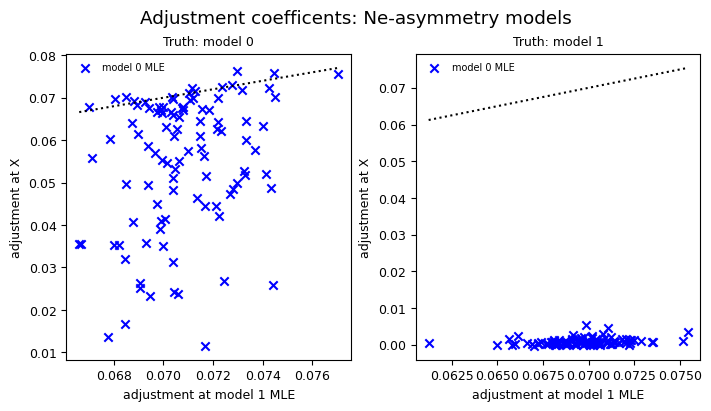

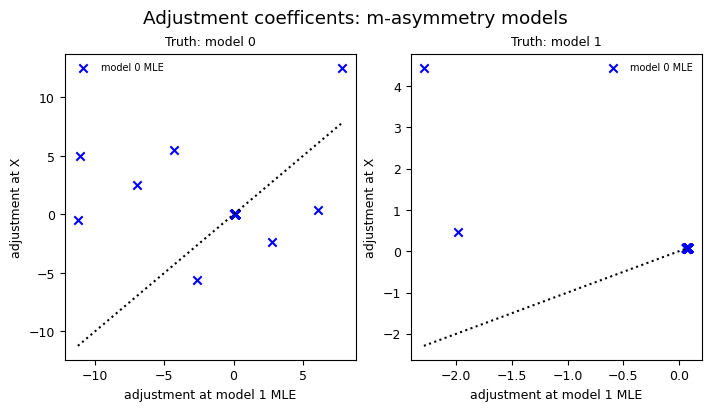

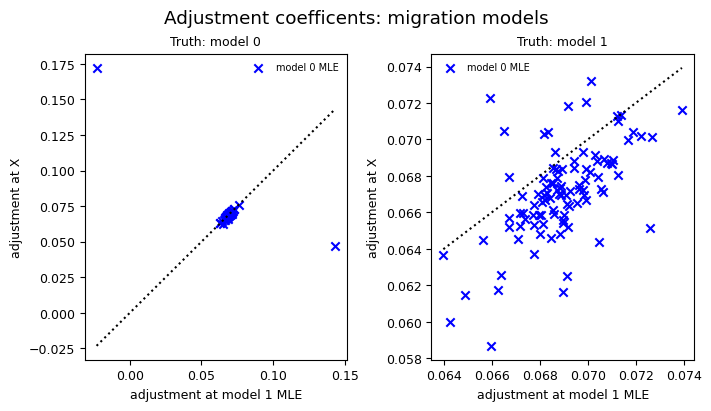

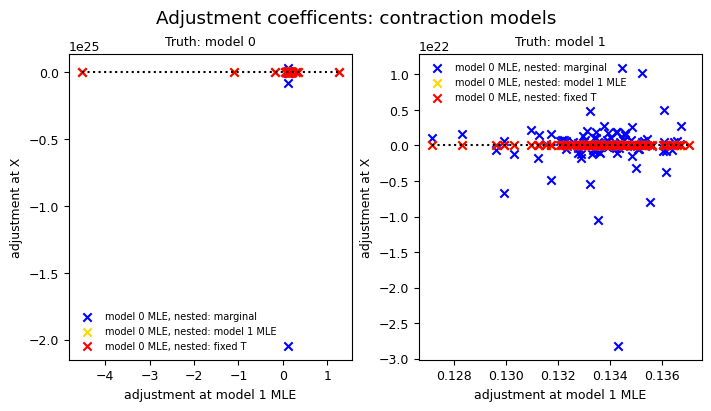

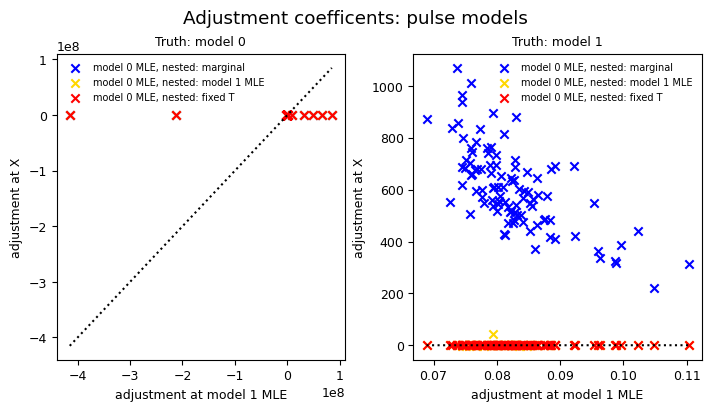

In [108]:
# Plot adjustments
def plot_adjustments(ax, xx, ys, labels=None, colors=None, title=None):
    for yy, label, color in zip(ys, labels, colors):
        ax.scatter(xx, yy, color=color, marker="x", label=label)
    ax.plot([np.min(xx), np.max(xx)], [np.min(xx), np.max(xx)],
        color="black", linestyle="dotted")
    ax.set_ylabel("adjustment at X")
    ax.set_xlabel("adjustment at model 1 MLE")
    ax.legend(framealpha=0)
    ax.set_title(title)

# Asymmetric size
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(7, 4), layout="constrained")
fig.suptitle("Adjustment coefficents: Ne-asymmetry models")
plot_adjustments(
    ax0, 
    asymmetric_size_0_df["adj1"], 
    [asymmetric_size_0_df["adj0"]], 
    colors=["blue"],
    labels=["model 0 MLE"],
    title="Truth: model 0"
)
plot_adjustments(
    ax1, 
    asymmetric_size_1_df["adj1"], 
    [asymmetric_size_1_df["adj0"]], 
    colors=["blue"],
    labels=["model 0 MLE"],
    title="Truth: model 1"
)
plt.savefig("figures/adjustments_asymmetric_sizes.pdf")


# Asymmetric migration
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(7, 4), layout="constrained")
fig.suptitle("Adjustment coefficents: m-asymmetry models")
plot_adjustments(
    ax0, 
    asymmetric_mig_0_df["adj1"], 
    [asymmetric_mig_0_df["adj0"]], 
    colors=["blue"],
    labels=["model 0 MLE"],
    title="Truth: model 0"
)
plot_adjustments(
    ax1, 
    asymmetric_mig_1_df["adj1"], 
    [asymmetric_mig_1_df["adj0"]], 
    colors=["blue"],
    labels=["model 0 MLE"],
    title="Truth: model 1"
)
plt.savefig("figures/adjustments_asymmetric_migration.pdf")


# Migration
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(7, 4), layout="constrained")
fig.suptitle("Adjustment coefficents: migration models")
plot_adjustments(
    ax0, 
    migration_0_df["adj1"], 
    [migration_0_df["adj0"]], 
    colors=["blue"],
    labels=["model 0 MLE"],
    title="Truth: model 0"
)
plot_adjustments(
    ax1, 
    migration_1_df["adj1"], 
    [migration_1_df["adj0"]], 
    colors=["blue"],
    labels=["model 0 MLE"],
    title="Truth: model 1"
)
plt.savefig("figures/adjustments_migration.pdf")


# Contraction
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(7, 4), layout="constrained")
fig.suptitle("Adjustment coefficents: contraction models")
plot_adjustments(
    ax0, 
    contraction_0_df["adj1"], 
    [contraction_0_df["adj0_0"], contraction_0_df["adj0_1"], contraction_0_df["adj0_2"]], 
    colors=["blue", "gold", "red"],
    labels=["model 0 MLE, nested: marginal",
        "model 0 MLE, nested: model 1 MLE",
        "model 0 MLE, nested: fixed T",],
    title="Truth: model 0"
)
plot_adjustments(
    ax1, 
    contraction_1_df["adj1"], 
    [contraction_1_df["adj0_0"], contraction_1_df["adj0_1"], contraction_1_df["adj0_2"]], 
    colors=["blue", "gold", "red"],
    labels=["model 0 MLE, nested: marginal",
        "model 0 MLE, nested: model 1 MLE",
        "model 0 MLE, nested: fixed T",],
    title="Truth: model 1"
)
plt.savefig("figures/adjustments_contraction.pdf")


# Pulse
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(7, 4), layout="constrained")
fig.suptitle("Adjustment coefficents: pulse models")
plot_adjustments(
    ax0, 
    pulse_0_df["adj1"], 
    [pulse_0_df["adj0_0"], pulse_0_df["adj0_1"], pulse_0_df["adj0_2"]], 
    colors=["blue", "gold", "red"],
    labels=["model 0 MLE, nested: marginal",
        "model 0 MLE, nested: model 1 MLE",
        "model 0 MLE, nested: fixed T",],
    title="Truth: model 0"
)
plot_adjustments(
    ax1, 
    pulse_1_df["adj1"], 
    [pulse_1_df["adj0_0"], pulse_1_df["adj0_1"], pulse_1_df["adj0_2"]], 
    colors=["blue", "gold", "red"],
    labels=["model 0 MLE, nested: marginal",
        "model 0 MLE, nested: model 1 MLE",
        "model 0 MLE, nested: fixed T",],
    title="Truth: model 1"
)
plt.savefig("figures/adjustments_pulse.pdf")

In [4]:
# Function for plotting LRT distributions
def plot_lrt_distribution(
    ax,
    arrs,
    labels=None,
    colors=None,
    max_x=None,
    n_bins=20,
    df=None,
    alpha=0.5,
    thresh=None,
    title=None
):  
    bins = np.linspace(0, max_x, n_bins)
    midpoints = (bins[1:] + bins[:-1]) / 2
    width = bins[-1] - bins[-2]
    xs = np.concatenate([[-2 * width], midpoints, [bins[-2] + 3 * width]])
    densities = []
    for arr in arrs:
        histogram = np.histogram(arr, bins, density=True)[0]
        below_0 = np.count_nonzero(arr < 0) / len(arr)
        above_max = np.count_nonzero(arr > max_x) / len(arr)
        density = np.concatenate([[below_0], histogram, [above_max]])
        densities.append(density)

    for ys, label, color in zip(densities, labels, colors):
        ax.bar(xs, ys, width=width, alpha=alpha, color=color, label=label,
            edgecolor="black")

    if df is not None:
        xx = np.linspace(0, xs[-2], 100)
        yy = scipy.stats.chi2.pdf(xx, df)
        ax.plot(xx, yy, color="black", label=rf"$\chi^2_{df}$ PDF")

    if thresh is not None:
        ax.vlines(thresh, 0, 1, transform=ax.get_xaxis_transform(),
            color="black", linestyles="dotted", label="rejection thresh.")
    ax.set_xticks([xs[0], xs[-1]], ["D<0", f"D>{max_x}"], minor=True, rotation=90)
    ax.set_ylim(0, )
    ax.set_ylabel("density")
    ax.set_xlabel("LRT statistic")
    ax.legend(framealpha=0)
    ax.set_title(title)

In [116]:
# Plot type I error rates
def plot_typeI_error(
    Dvals, 
    weights=None, 
    labels=None, 
    colors=None, 
    out=None,
    title=None
):
    fig, ax = plt.subplots(figsize=(4, 4), layout="constrained")
    alphas = np.linspace(0, 1, 101)

    for Ds, label, color in zip(Dvals, labels, colors):
        pvals = [moments.Godambe.sum_chi2_ppf(x, weights) for x in Ds]
        error = np.array([np.count_nonzero(pvals < a) / len(pvals) for a in alphas])                        
        plt.step(alphas, error, color=color, label=label)
    ax.plot([0, 1], [0, 1], color="black", linestyle="dotted")
    ax.set_ylim(0, 1)
    ax.set_xlim(0, 1)
    ax.set_ylabel("type I error rate")
    ax.set_xlabel("alpha")
    ax.invert_xaxis()
    ax.legend(framealpha=0)
    ax.set_title(title)
    if out is not None:
        plt.savefig(out)

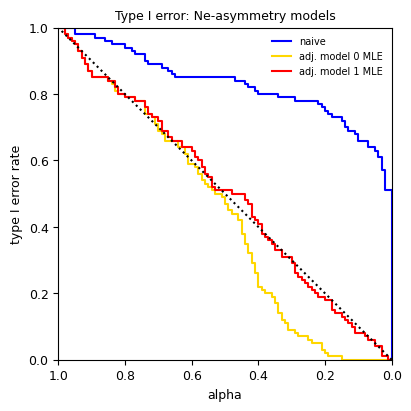

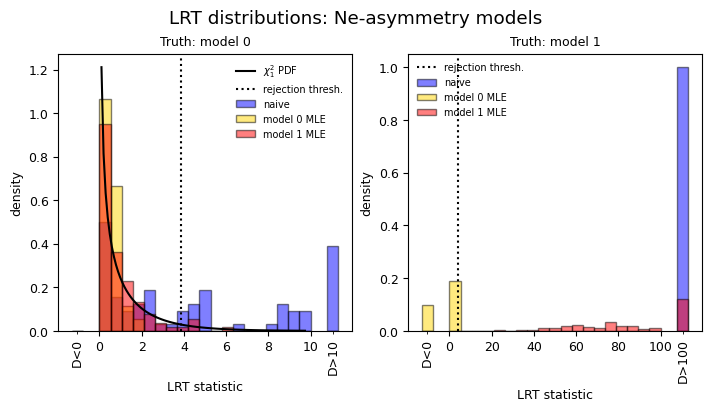

In [117]:
# Plot LRT distributions for asymmetric size models
labels = ["naive", "adj. model 0 MLE", "adj. model 1 MLE"]
colors = ["blue", "gold", "red"]

D0_0 = np.array(asymmetric_size_0_df["D_naive"])
D0_1 = np.array(asymmetric_size_0_df["adj0"]) * D0_0
D0_2 = np.array(asymmetric_size_0_df["adj1"]) * D0_0

plot_typeI_error(
    [D0_0, D0_1, D0_2],
    weights=(0, 1),
    labels=labels,
    colors=colors,
    title="Type I error: Ne-asymmetry models",
    out="figures/type_I_error_asymmetric_sizes.pdf"
)

thresh = scipy.stats.chi2.isf(0.05, 1)
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(7, 4), layout="constrained")
fig.suptitle("LRT distributions: Ne-asymmetry models")

plot_lrt_distribution(
    ax0, 
    [D0_0, D0_1, D0_2], 
    labels=["naive", "model 0 MLE", "model 1 MLE"],
    colors=["blue", "gold", "red"], 
    max_x=10,
    df=1,
    thresh=thresh,
    title="Truth: model 0"
)

D1_0 = np.array(asymmetric_size_1_df["D_naive"])
D1_1 = np.array(asymmetric_size_1_df["adj0"]) * D1_0
D1_2 = np.array(asymmetric_size_1_df["adj1"]) * D1_0
plot_lrt_distribution(
    ax1, 
    [D1_0, D1_1, D1_2], 
    labels=["naive", "model 0 MLE", "model 1 MLE"],
    colors=["blue", "gold", "red"], 
    max_x=100,
    thresh=thresh,
    title="Truth: model 1"
)
plt.savefig("figures/adj_LRT_asymmetric_sizes.pdf")

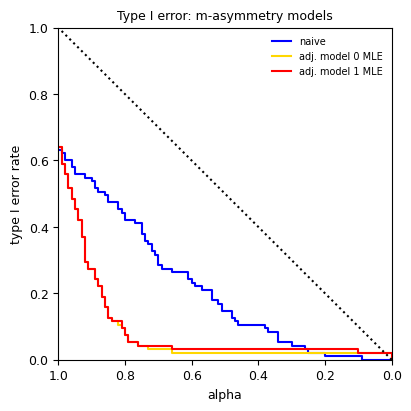

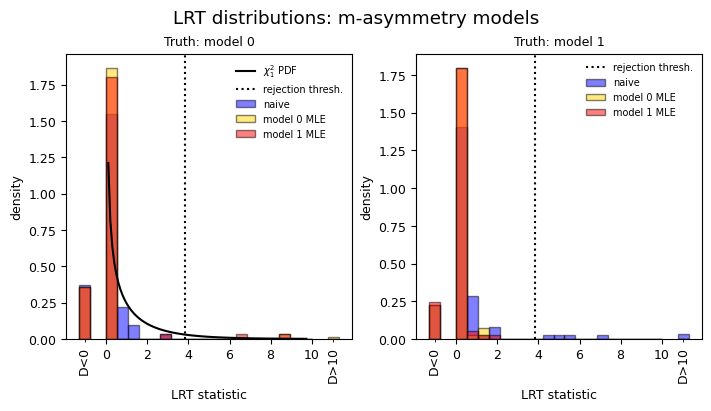

In [118]:
# Plot LRT distributions for symmetric migration models
labels = ["naive", "adj. model 0 MLE", "adj. model 1 MLE"]
colors = ["blue", "gold", "red"]

D0_0 = np.array(asymmetric_mig_0_df["D_naive"])
D0_1 = np.array(asymmetric_mig_0_df["adj0"]) * D0_0
D0_2 = np.array(asymmetric_mig_0_df["adj1"]) * D0_0

plot_typeI_error(
    [D0_0, D0_1, D0_2],
    weights=(0, 1),
    labels=labels,
    colors=colors,
    title="Type I error: m-asymmetry models",
    out="figures/type_I_error_asymmetric_migration.pdf"
)


thresh = scipy.stats.chi2.isf(0.05, 1)
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(7, 4), layout="constrained")
fig.suptitle("LRT distributions: m-asymmetry models")

plot_lrt_distribution(
    ax0, 
    [D0_0, D0_1, D0_2], 
    labels=["naive", "model 0 MLE", "model 1 MLE"],
    colors=["blue", "gold", "red"], 
    max_x=10,
    df=1,
    thresh=thresh,
    title="Truth: model 0"
)

D1_0 = np.array(asymmetric_mig_1_df["D_naive"])
D1_1 = np.array(asymmetric_mig_1_df["adj0"]) * D1_0
D1_2 = np.array(asymmetric_mig_1_df["adj1"]) * D1_0
plot_lrt_distribution(
    ax1, 
    [D1_0, D1_1, D1_2], 
    labels=["naive", "model 0 MLE", "model 1 MLE"],
    colors=["blue", "gold", "red"], 
    max_x=10,
    thresh=thresh,
    title="Truth: model 1"
)
plt.savefig("figures/adj_LRT_asymmetric_migration.pdf")

0.05017412323114523


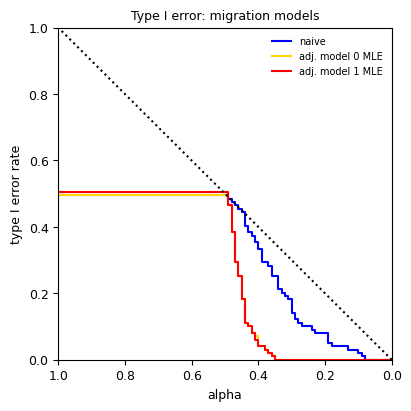

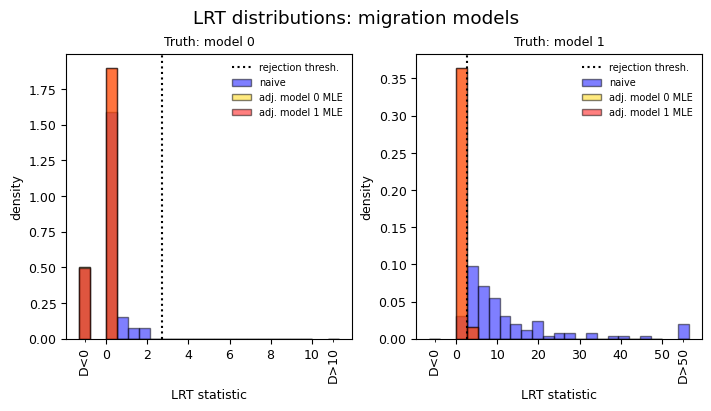

In [122]:
# Plot LRT distributions for migration models
labels=["naive", "adj. model 0 MLE", "adj. model 1 MLE"]
colors = ["blue", "gold", "red"]
weights = (0.5, 0.5)

D0_0 = np.array(migration_0_df["D_naive"])
D0_1 = np.array(migration_0_df["adj0"]) * D0_0
D0_2 = np.array(migration_0_df["adj1"]) * D0_0

plot_typeI_error(
    [D0_0, D0_1, D0_2],
    weights=weights,
    labels=labels,
    colors=colors,
    title="Type I error: migration models",
    out="figures/type_I_error_migration.pdf"
)


thresh = 2.7
print(moments.Godambe.sum_chi2_ppf(thresh, weights))
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(7, 4), layout="constrained")
fig.suptitle("LRT distributions: migration models")

plot_lrt_distribution(
    ax0, 
    [D0_0, D0_1, D0_2], 
    labels=labels,
    colors=colors, 
    max_x=10,
    thresh=thresh,
    title="Truth: model 0"
)

D1_0 = np.array(migration_1_df["D_naive"])
D1_1 = np.array(migration_1_df["adj0"]) * D1_0
D1_2 = np.array(migration_1_df["adj1"]) * D1_0
plot_lrt_distribution(
    ax1, 
    [D1_0, D1_1, D1_2], 
    labels=labels,
    colors=colors, 
    max_x=50,
    thresh=thresh,
    title="Truth: model 1"
)
plt.savefig("figures/adj_LRT_migration.pdf")

0.04970009794096475


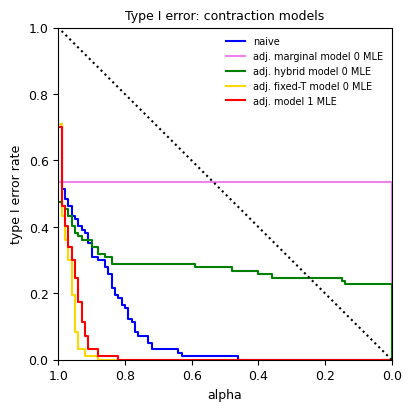

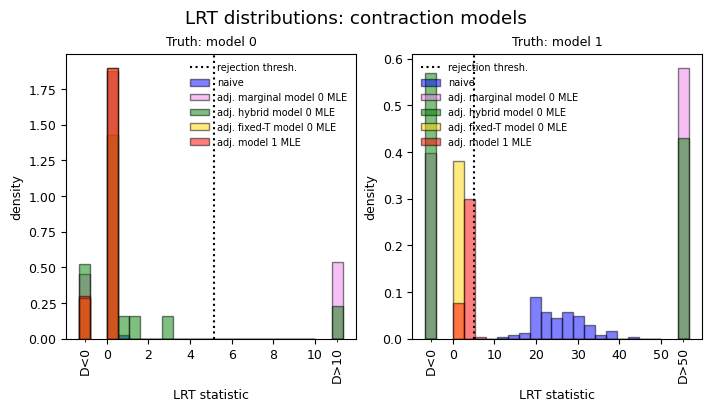

In [123]:
# Plot LRT distributions for contraction models
labels=[
    "naive", 
    "adj. marginal model 0 MLE",
    "adj. hybrid model 0 MLE",
    "adj. fixed-T model 0 MLE",
    "adj. model 1 MLE"
]
colors = ["blue", "violet", "green", "gold", "red"]
weights = (0, 0.5, 0.5)

D0_0 = 2 * (np.array(contraction_0_df["ll1"]) - np.array(contraction_0_df["ll0"]))
D0_1 = np.array(contraction_0_df["adj0_0"]) * D0_0
D0_2 = np.array(contraction_0_df["adj0_1"]) * D0_0
D0_3 = np.array(contraction_0_df["adj0_2"]) * D0_0
D0_4 = np.array(contraction_0_df["adj1"]) * D0_0

plot_typeI_error(
    [D0_0, D0_1, D0_2, D0_3, D0_4],
    labels=labels,
    colors=colors,
    weights=weights,
    title="Type I error: contraction models",
    out="figures/type_I_error_contraction.pdf"
)


thresh = 5.15
print(moments.Godambe.sum_chi2_ppf(thresh, weights))
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(7, 4), layout="constrained")
fig.suptitle("LRT distributions: contraction models")

plot_lrt_distribution(
    ax0, 
    [D0_0, D0_1, D0_2, D0_3, D0_4], 
    labels=labels,
    colors=colors,
    max_x=10,
    thresh=thresh,
    title="Truth: model 0"
)

D1_0 = 2 * (np.array(contraction_1_df["ll1"]) - np.array(contraction_1_df["ll0"]))
D1_1 = np.array(contraction_1_df["adj0_0"]) * D1_0
D1_2 = np.array(contraction_1_df["adj0_1"]) * D1_0
D1_3 = np.array(contraction_1_df["adj0_2"]) * D1_0
D1_4 = np.array(contraction_1_df["adj1"]) * D1_0
plot_lrt_distribution(
    ax1, 
    [D1_0, D1_1, D1_2, D1_3, D1_4], 
    labels=labels,
    colors=colors,
    max_x=50,
    thresh=thresh,
    title="Truth: model 1"
)
plt.savefig("figures/adj_LRT_contraction.pdf")

0.04970009794096475


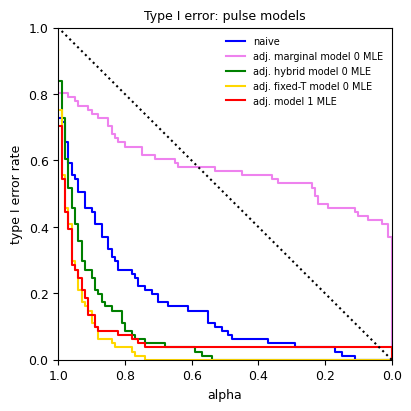

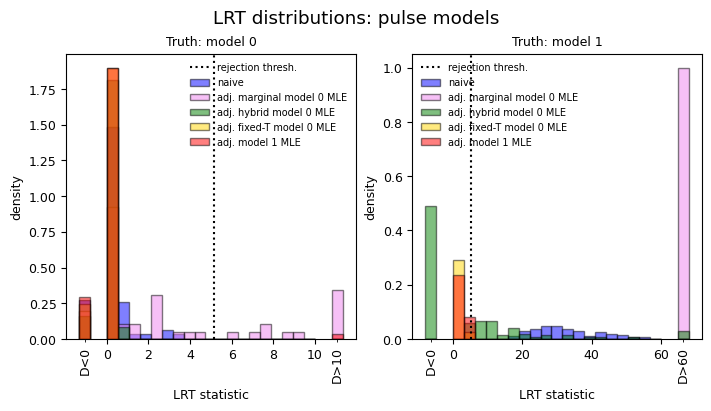

In [172]:
# Plot LRT distributions for pulse models
labels=[
    "naive", 
    "adj. marginal model 0 MLE",
    "adj. hybrid model 0 MLE",
    "adj. fixed-T model 0 MLE",
    "adj. model 1 MLE"
]
colors = ["blue", "violet", "green", "gold", "red"]
weights = (0, 0.5, 0.5)

D0_0 = 2 * (np.array(pulse_0_df["ll1"]) - np.array(pulse_0_df["ll0"]))
D0_1 = np.array(pulse_0_df["adj0_0"]) * D0_0
D0_2 = np.array(pulse_0_df["adj0_1"]) * D0_0
D0_3 = np.array(pulse_0_df["adj0_2"]) * D0_0
D0_4 = np.array(pulse_0_df["adj1"]) * D0_0

plot_typeI_error(
    [D0_0, D0_1, D0_2, D0_3, D0_4],
    weights=weights,
    labels=labels,
    colors=colors,
    title="Type I error: pulse models",
    out="figures/type_I_error_pulse.pdf"
)

thresh = 5.15
print(moments.Godambe.sum_chi2_ppf(thresh, (0, 0.5, 0.5)))
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(7, 4), layout="constrained")
fig.suptitle("LRT distributions: pulse models")

plot_lrt_distribution(
    ax0, 
    [D0_0, D0_1, D0_2, D0_3, D0_4], 
    labels=labels,
    colors=colors,
    max_x=10,
    thresh=thresh,
    title="Truth: model 0"
)

D1_0 = 2 * (np.array(pulse_1_df["ll1"]) - np.array(pulse_1_df["ll0"]))
D1_1 = np.array(pulse_1_df["adj0_0"]) * D1_0
D1_2 = np.array(pulse_1_df["adj0_1"]) * D1_0
D1_3 = np.array(pulse_1_df["adj0_2"]) * D1_0
D1_4 = np.array(pulse_1_df["adj1"]) * D1_0
plot_lrt_distribution(
    ax1, 
    [D1_0, D1_1, D1_2, D1_3, D1_4], 
    labels=labels,
    colors=colors,
    max_x=60,
    thresh=thresh,
    title="Truth: model 1"
)
plt.savefig("figures/adj_LRT_pulse.pdf")

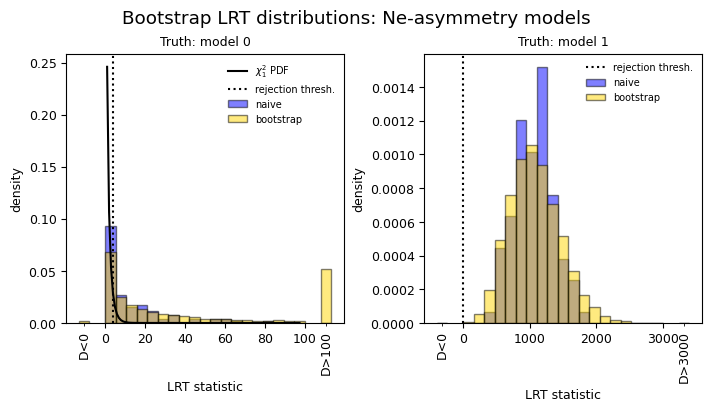

In [170]:
thresh = scipy.stats.chi2.isf(0.05, 1)
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(7, 4), layout="constrained")
fig.suptitle("Bootstrap LRT distributions: Ne-asymmetry models")

labels = ["naive",  "bootstrap"]
colors = ["blue", "gold"]

D0 = 2 * (np.array(asymmetric_size_0_df["ll1"]) - np.array(asymmetric_size_0_df["ll0"]))
D0b = np.array(asymmetric_size_0_boot_df).flatten()

D1 = 2 * (np.array(asymmetric_size_1_df["ll1"]) - np.array(asymmetric_size_1_df["ll0"]))
D1b = np.array(asymmetric_size_1_boot_df).flatten()

plot_lrt_distribution(
    ax0, 
    [D0, D0b], 
    labels=labels,
    colors=colors, 
    max_x=100,
    df=1,
    thresh=thresh,
    title="Truth: model 0"
)
plot_lrt_distribution(
    ax1, 
    [D1, D1b], 
    labels=labels,
    colors=colors, 
    max_x=3000,
    thresh=thresh,
    title="Truth: model 1"
)

plt.savefig("figures/bootstrap_LRT_asymmetric_size.pdf")

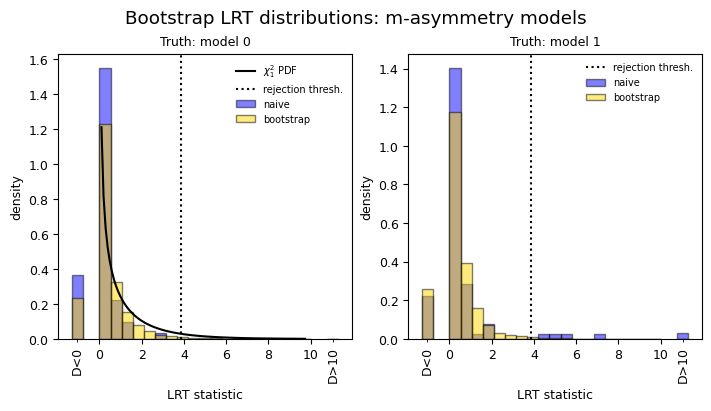

In [ ]:
thresh = scipy.stats.chi2.isf(0.05, 1)
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(7, 4), layout="constrained")
fig.suptitle("Bootstrap LRT distributions: m-asymmetry models")

labels = ["naive",  "bootstrap"]
colors = ["blue", "gold"]

D0 = 2 * (np.array(asymmetric_mig_0_df["ll1"]) - np.array(asymmetric_mig_0_df["ll0"]))
D0b = np.array(asymmetric_mig_0_boot_df).flatten()

D1 = 2 * (np.array(asymmetric_mig_1_df["ll1"]) - np.array(asymmetric_mig_1_df["ll0"]))
D1b = np.array(asymmetric_mig_1_boot_df).flatten()

plot_lrt_distribution(
    ax0, 
    [D0, D0b], 
    labels=labels,
    colors=colors, 
    max_x=10,
    df=1,
    thresh=thresh,
    title="Truth: model 0"
)
plot_lrt_distribution(
    ax1, 
    [D1, D1b], 
    labels=labels,
    colors=colors, 
    max_x=10,
    thresh=thresh,
    title="Truth: model 1"
)

plt.savefig("figures/bootstrap_LRT_asymmetric_mig.pdf")

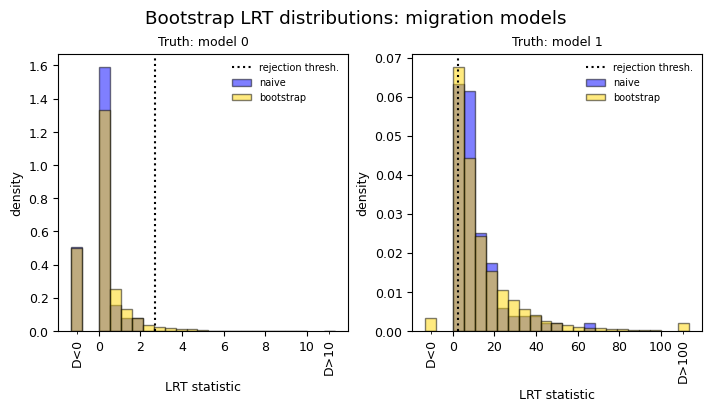

In [ ]:
thresh = 2.7
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(7, 4), layout="constrained")
fig.suptitle("Bootstrap LRT distributions: migration models")

labels = ["naive", "bootstrap"]
colors = ["blue", "gold"]

D0 = 2 * (np.array(migration_0_df["ll1"]) - np.array(migration_0_df["ll0"]))
D0b = np.array(migration_0_boot_df).flatten()

D1 = 2 * (np.array(migration_1_df["ll1"]) - np.array(migration_1_df["ll0"]))
D1b = np.array(migration_1_boot_df).flatten()

plot_lrt_distribution(
    ax0, 
    [D0, D0b], 
    labels=labels,
    colors=colors, 
    max_x=10,
    thresh=thresh,
    title="Truth: model 0"
)
plot_lrt_distribution(
    ax1, 
    [D1, D1b], 
    labels=labels,
    colors=colors, 
    max_x=100,
    thresh=thresh,
    title="Truth: model 1"
)

plt.savefig("figures/bootstrap_LRT_migration.pdf")

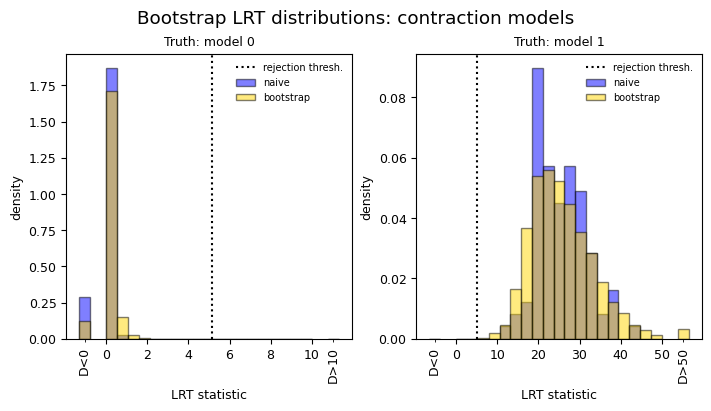

In [ ]:
thresh = 5.15
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(7, 4), layout="constrained")
fig.suptitle("Bootstrap LRT distributions: contraction models")

labels = ["naive",  "bootstrap"]
colors = ["blue", "gold"]

D0 = 2 * (np.array(contraction_0_df["ll1"]) - np.array(contraction_0_df["ll0"]))
D0b = np.array(contraction_0_boot_df).flatten()

D1 = 2 * (np.array(contraction_1_df["ll1"]) - np.array(contraction_1_df["ll0"]))
D1b = np.array(contraction_1_boot_df).flatten()

plot_lrt_distribution(
    ax0, 
    [D0, D0b], 
    labels=labels,
    colors=colors, 
    max_x=10,
    thresh=thresh,
    title="Truth: model 0"
)
plot_lrt_distribution(
    ax1, 
    [D1, D1b], 
    labels=labels,
    colors=colors, 
    max_x=50,
    thresh=thresh,
    title="Truth: model 1"
)

plt.savefig("figures/bootstrap_LRT_contraction.pdf")

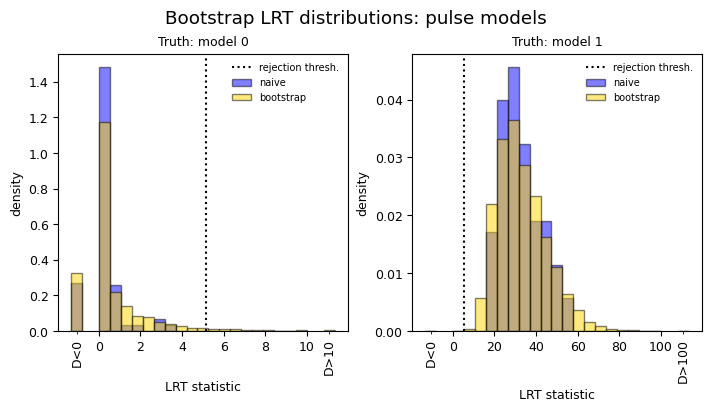

In [ ]:
thresh = 5.15
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(7, 4), layout="constrained")
fig.suptitle("Bootstrap LRT distributions: pulse models")

labels = ["naive", "bootstrap"]
colors = ["blue", "gold"]

D0 = 2 * (np.array(pulse_0_df["ll1"]) - np.array(pulse_0_df["ll0"]))
D0b = np.array(pulse_0_boot_df).flatten()

D1 = 2 * (np.array(pulse_1_df["ll1"]) - np.array(pulse_1_df["ll0"]))
D1b = np.array(pulse_1_boot_df).flatten()

plot_lrt_distribution(
    ax0, 
    [D0, D0b], 
    labels=labels,
    colors=colors, 
    max_x=10,
    thresh=thresh,
    title="Truth: model 0"
)
plot_lrt_distribution(
    ax1, 
    [D1, D1b], 
    labels=labels,
    colors=colors, 
    max_x=100,
    thresh=thresh,
    title="Truth: model 1"
)

plt.savefig("figures/bootstrap_LRT_pulse.pdf")

In [184]:
# Computing rejection rates. 
# The naive LRT statistic is overdispersed so we have high false positive rates
weights = (0, 1)
alpha = 0.05
for ii in range(len(pulse_0_boot_df.columns)):
    ex0 = np.array(pulse_0_boot_df[f"rep{ii}"])
    ex1 = np.array(pulse_1_boot_df[f"rep{ii}"])
    pvals0 = np.array([moments.Godambe.sum_chi2_ppf(x, weights) for x in ex0])
    pvals1 = np.array([moments.Godambe.sum_chi2_ppf(x, weights) for x in ex1])
    false_pos_rate = np.count_nonzero(pvals0 < alpha) / len(pvals0)    
    true_pos_rate = np.count_nonzero(pvals1 < alpha) / len(pvals1)    
    print(false_pos_rate, true_pos_rate)

0.17 1.0
0.0 1.0
0.01 1.0
0.0 1.0
0.12 1.0
0.01 1.0
0.02 1.0
0.12 1.0
0.12 1.0
0.0 1.0
0.0 1.0
0.0 1.0
0.1 1.0
0.0 1.0
0.08 1.0
0.2 1.0
0.0 1.0
0.01 1.0
0.02 1.0
0.05 1.0
0.0 1.0
0.01 1.0
0.0 1.0
0.04 1.0
0.0 1.0
0.04 1.0
0.0 1.0
0.01 1.0
0.0 1.0
0.01 1.0
0.13 1.0
0.04 1.0
0.02 1.0
0.04 1.0
0.01 1.0
0.0 1.0
0.0 1.0
0.0 1.0
0.0 1.0
0.0 1.0
0.48 1.0
0.01 1.0
0.0 1.0
0.01 1.0
0.02 1.0
0.01 1.0
0.0 1.0
0.0 1.0
0.0 1.0
0.02 1.0
0.0 1.0
0.04 1.0
0.0 1.0
0.0 1.0
0.02 1.0
0.0 1.0
0.01 1.0
0.0 1.0
0.06 1.0
0.0 1.0
0.0 1.0
0.07 1.0
0.0 1.0
0.01 1.0
0.0 1.0
0.0 1.0
0.0 1.0
0.42 1.0
0.0 1.0
0.0 1.0
0.01 1.0
0.01 1.0
0.0 1.0
0.0 1.0
0.06 1.0
0.0 1.0
0.0 1.0
0.02 1.0
0.02 1.0
0.0 1.0
0.52 1.0


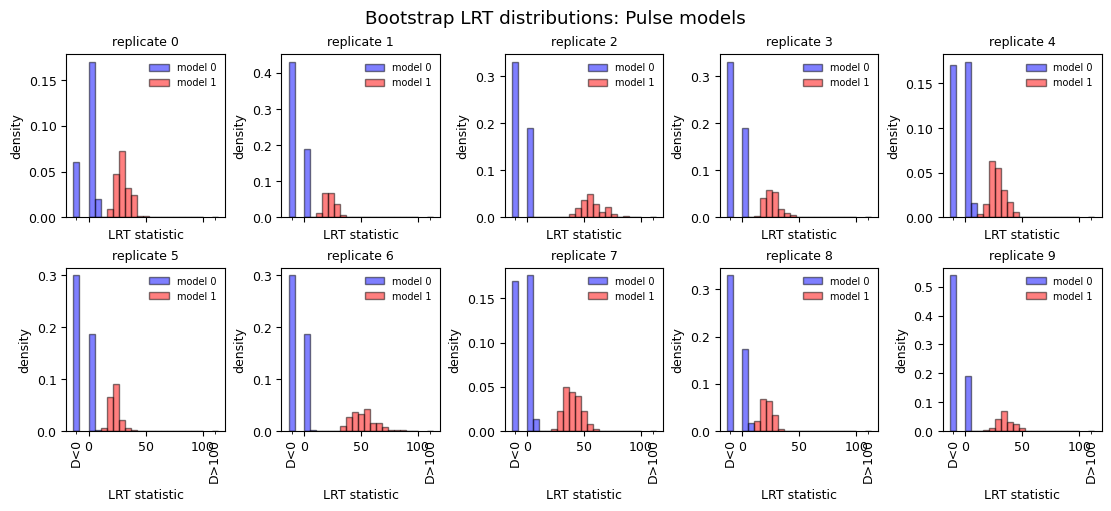

In [25]:
alphas = np.linspace(0, 1, 101)
weights = (0, 0.5, 0.5)

fig, axs = plt.subplots(2, 5, figsize=(11, 5), layout="constrained",
    sharex=True,)
fig.suptitle("Bootstrap LRT distributions: Pulse models")
axs = axs.flatten()

for i in range(10):
    ex0 = np.array(pulse_0_boot_df[f"rep{i}"])
    ex1 = np.array(pulse_1_boot_df[f"rep{i}"])
    plot_lrt_distribution(
        axs[i], 
        [ex0, ex1], 
        labels=["model 0", "model 1"],
        colors=["blue", "red"], 
        max_x=100,
        title=f"replicate {i}"
    )
plt.savefig("figures/example_bootstrap_LRT_distr_pulse.pdf")

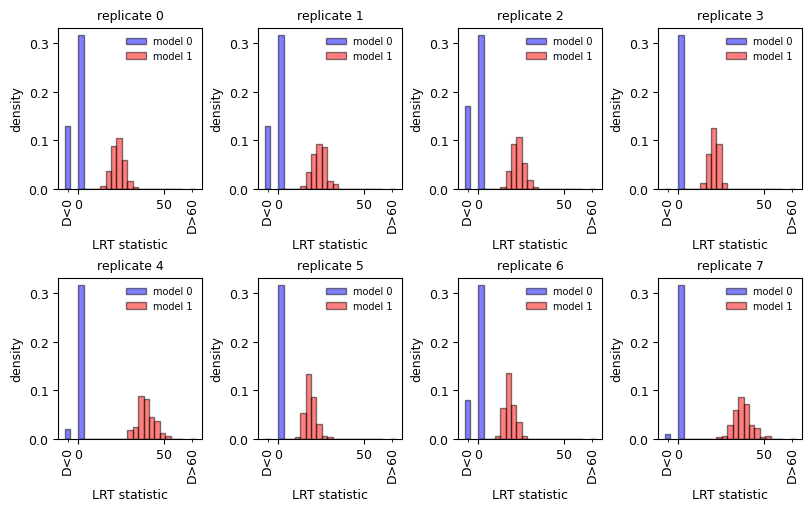

In [18]:
alphas = np.linspace(0, 1, 101)
weights = (0, 0.5, 0.5)

fig, axs = plt.subplots(2, 4, figsize=(8, 5), layout="constrained")
axs = axs.flatten()

for i in range(8):
    ex0 = np.array(contraction_0_boot_df[f"rep{i}"])
    ex1 = np.array(contraction_1_boot_df[f"rep{i}"])
    plot_lrt_distribution(
        axs[i], 
        [ex0, ex1], 
        labels=["model 0", "model 1"],
        colors=["blue", "red"], 
        max_x=60,
        title=f"replicate {i}"
    )
